## data overview


In [2]:
import pandas as pd

data = pd.read_csv(
    "../datasets/w3classif.csv", header=None, names=["feature1", "feature2", "label"]
)

In [3]:
print(f"data.shape:\n{data.shape}")

data.shape:
(400, 3)


In [4]:
print(f"data.head():\n{data.head()}")

data.head():
   feature1  feature2  label
0  0.475861  0.541139      0
1  1.412233 -1.540877      0
2  0.022608 -0.203143      0
3 -0.047869 -0.499965      0
4  1.701335  0.383024      0


In [5]:
print("data.info():")
data.info()

data.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  400 non-null    float64
 1   feature2  400 non-null    float64
 2   label     400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [6]:
print(f"data.describe():\n{data.describe()}")

data.describe():
         feature1    feature2       label
count  400.000000  400.000000  400.000000
mean     1.504300    1.610388    0.500000
std      2.045366    2.071835    0.500626
min     -3.232038   -3.072989    0.000000
25%     -0.043643   -0.193087    0.000000
50%      1.084154    1.385823    0.500000
75%      3.105206    3.252946    1.000000
max      7.423639    7.095566    1.000000


In [7]:
print(f"data['label'].value_counts():\n{data['label'].value_counts()}")

data['label'].value_counts():
label
0    200
1    200
Name: count, dtype: int64


## Missing Values


In [8]:
data.isnull().sum()

feature1    0
feature2    0
label       0
dtype: int64

## Visual analysis

### scatterplot


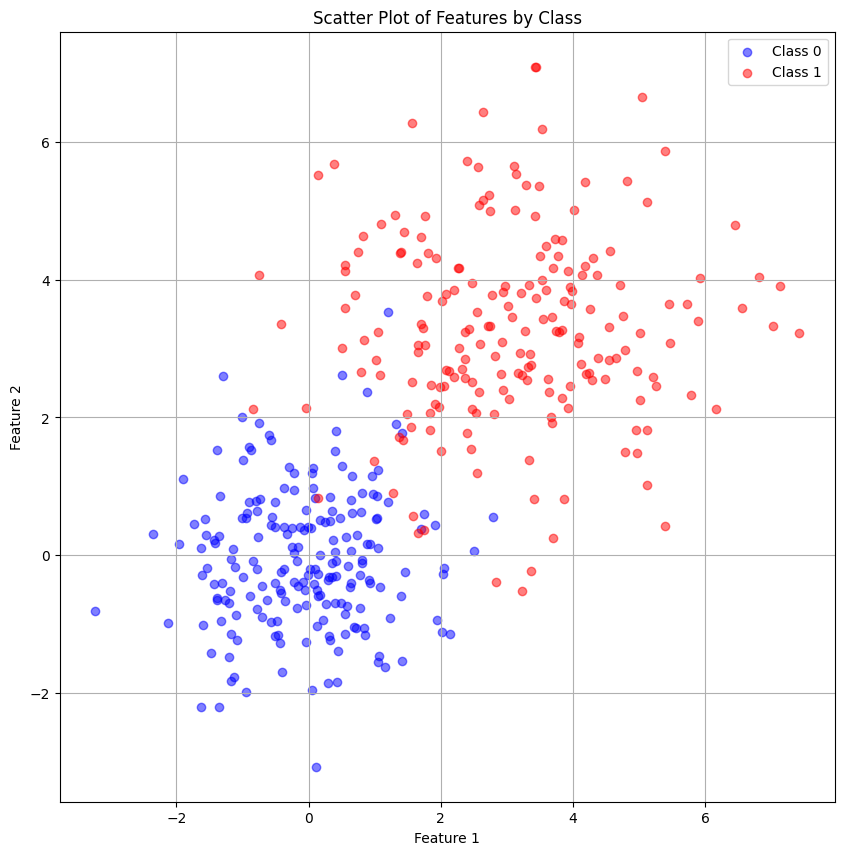

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

class_0 = data[data["label"] == 0]
class_1 = data[data["label"] == 1]

plt.scatter(
    class_0["feature1"], class_0["feature2"], color="blue", label="Class 0", alpha=0.5
)
plt.scatter(
    class_1["feature1"], class_1["feature2"], color="red", label="Class 1", alpha=0.5
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Features by Class")
plt.legend()
plt.grid()
plt.show()

### Feature distribution histogram


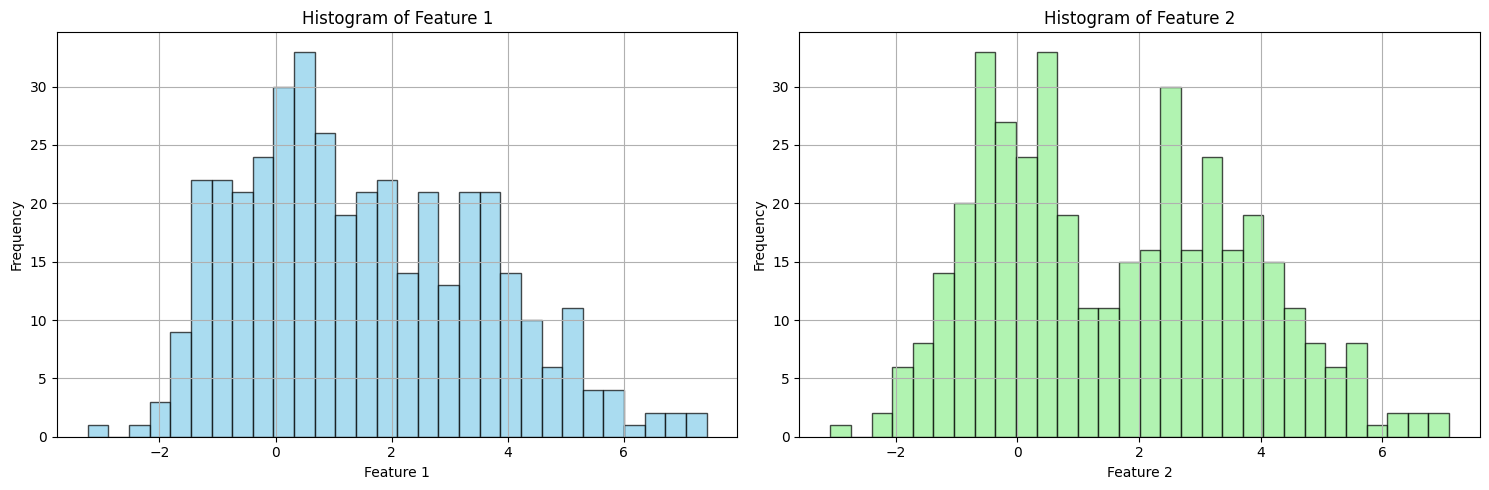

In [10]:
import matplotlib.pyplot as plt

# 创建1行2列的子图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左侧图：Feature 1 histogram
axes[0].hist(
    data["feature1"],
    bins=30,
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
)
axes[0].set_title("Histogram of Feature 1")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# 右侧图：Feature 2 histogram
axes[1].hist(
    data["feature2"],
    bins=30,
    alpha=0.7,
    color="lightgreen",
    edgecolor="black",
)
axes[1].set_title("Histogram of Feature 2")
axes[1].set_xlabel("Feature 2")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

plt.tight_layout()  # 自动调整子图间距
plt.show()

### Category Distribution Pie Chart


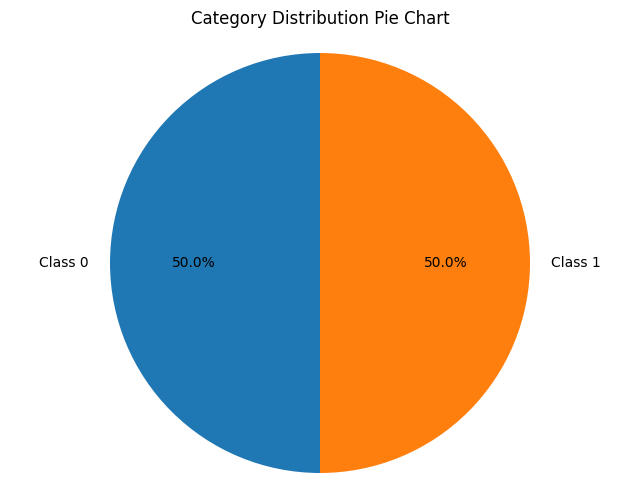

In [11]:
class_counts = data["label"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    class_counts,
    labels=[f"Class {i}" for i in class_counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Category Distribution Pie Chart")
plt.axis("equal")  # Equal aspect ratio ensures that pie chart is a circle.
plt.show()

### boxplot


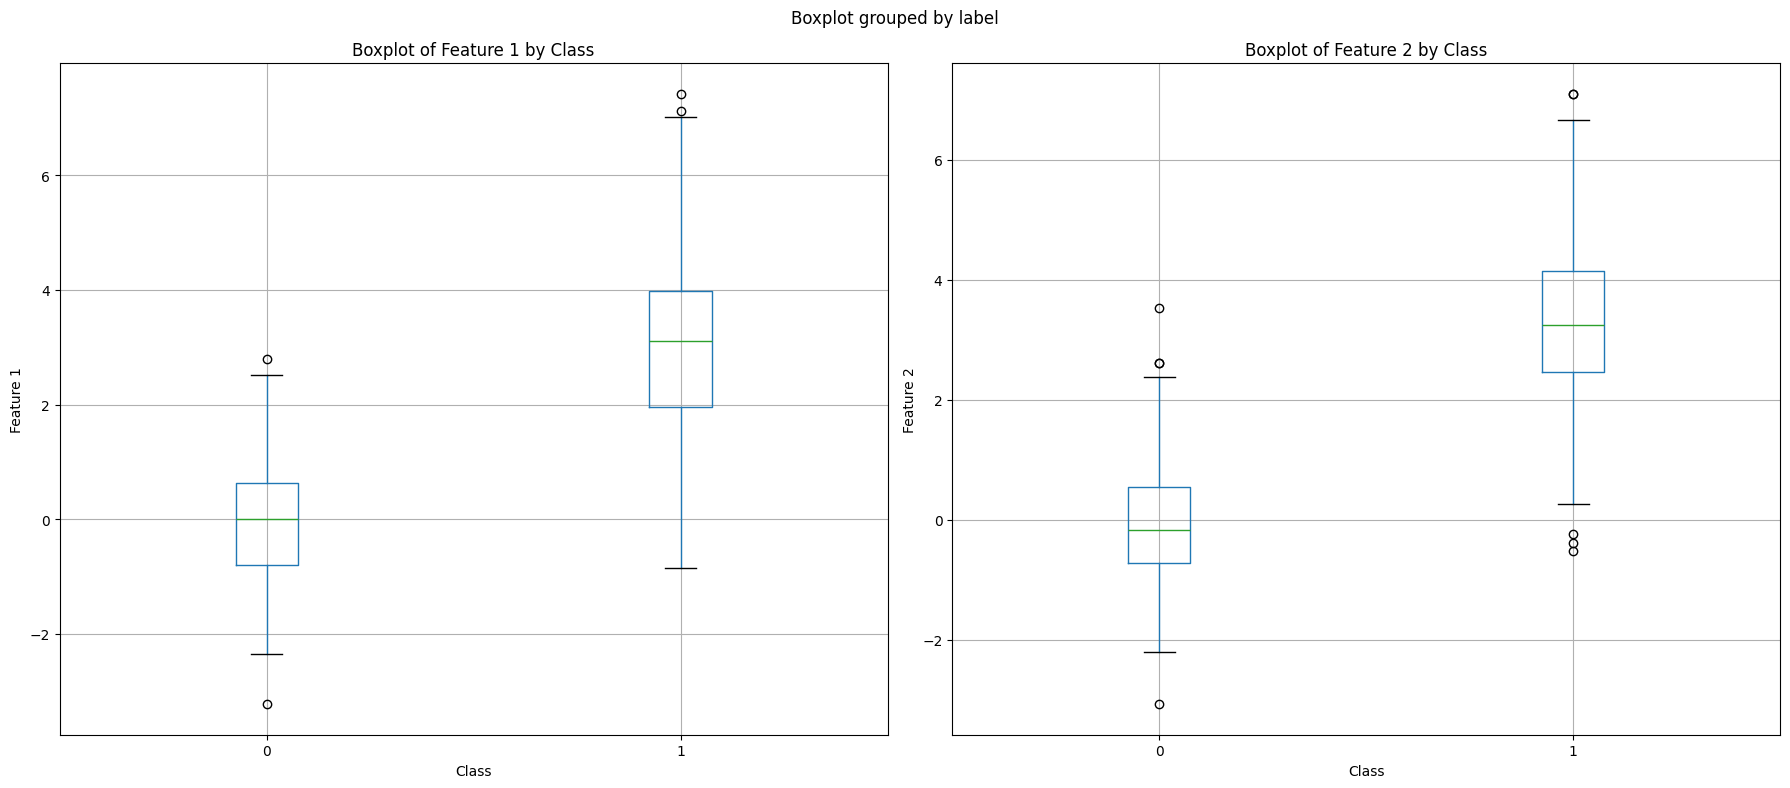

In [15]:
# 创建并排的箱线图对比
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Feature 1 boxplot
data.boxplot(column="feature1", by="label", ax=axes[0])
axes[0].set_title("Boxplot of Feature 1 by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Feature 1")

# Feature 2 boxplot
data.boxplot(column="feature2", by="label", ax=axes[1])
axes[1].set_title("Boxplot of Feature 2 by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Correlation heatmap


=== 特征相关性 ===
          feature1  feature2     label
feature1  1.000000  0.637402  0.769057
feature2  0.637402  1.000000  0.808844
label     0.769057  0.808844  1.000000


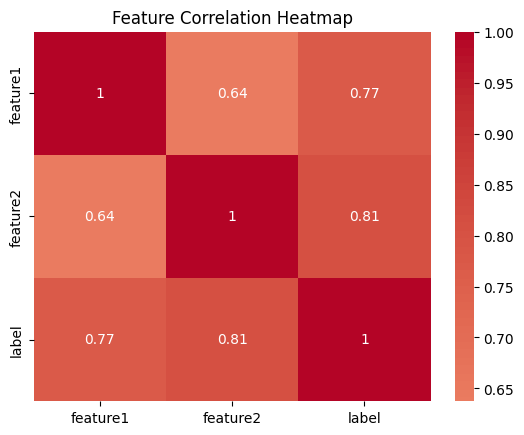

In [16]:
import seaborn as sns

print("\n=== 特征相关性 ===")
correlation_matrix = data.corr()
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

## Category separability analysis

In [ ]:
print("\n=== 类别可分性分析 ===")
for feature in ["feature1", "feature2"]:
    class_0_mean = data[data["label"] == 0][feature].mean()
    class_1_mean = data[data["label"] == 1][feature].mean()
    overall_std = data[feature].std()

    separation = abs(class_0_mean - class_1_mean) / overall_std
    print(f"{feature}: 类别间距离/标准差 = {separation:.3f}")


=== 类别可分性分析 ===
feature1: 类别间距离/标准差 = 1.536
feature2: 类别间距离/标准差 = 1.616


=== 详细的类别可分性分析 ===

feature1:
  Class 0 平均值: -0.067
  Class 1 平均值: 3.075
  平均值差距: 3.142
  整体标准差: 2.045
  可分性指标: 1.536
  → 可分性很好！这个特征对分类很有用

feature2:
  Class 0 平均值: -0.063
  Class 1 平均值: 3.284
  平均值差距: 3.347
  整体标准差: 2.072
  可分性指标: 1.616
  → 可分性很好！这个特征对分类很有用


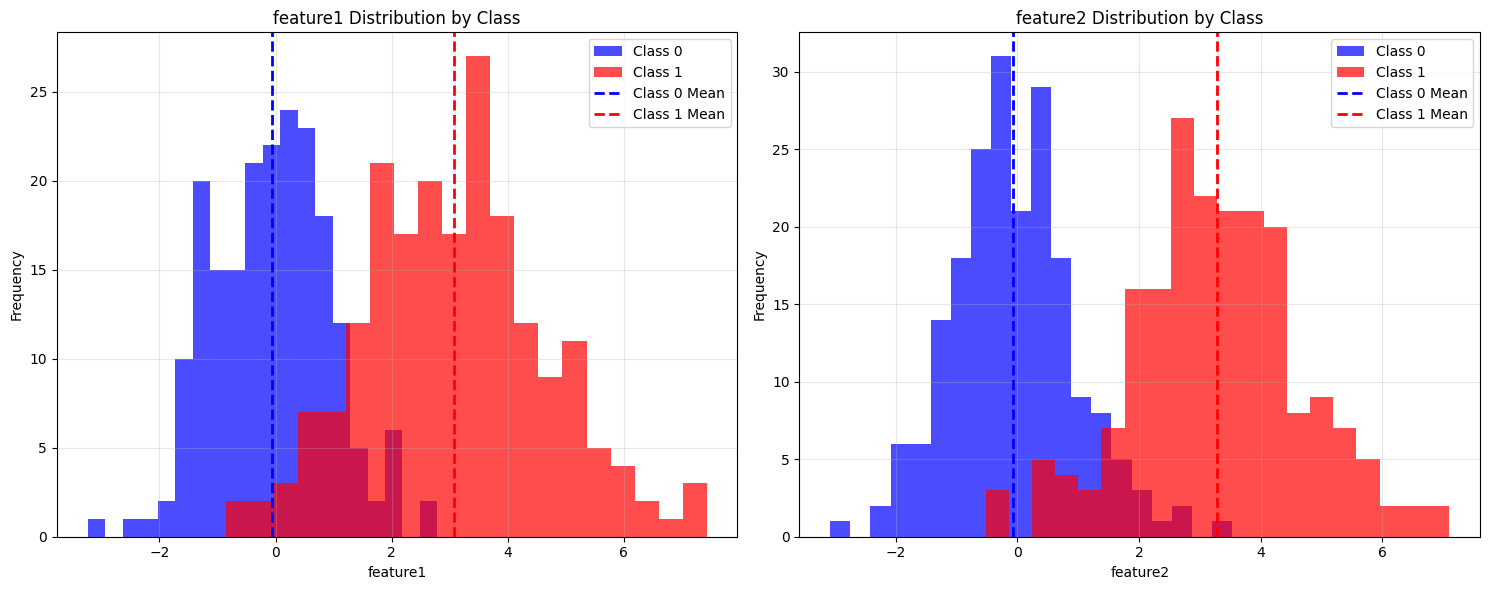

In [22]:
print("=== 详细的类别可分性分析 ===")
for feature in ["feature1", "feature2"]:
    class_0_data = data[data["label"] == 0][feature]
    class_1_data = data[data["label"] == 1][feature]

    class_0_mean = class_0_data.mean()
    class_1_mean = class_1_data.mean()
    overall_std = data[feature].std()

    separation = abs(class_0_mean - class_1_mean) / overall_std

    print(f"\n{feature}:")
    print(f"  Class 0 平均值: {class_0_mean:.3f}")
    print(f"  Class 1 平均值: {class_1_mean:.3f}")
    print(f"  平均值差距: {abs(class_0_mean - class_1_mean):.3f}")
    print(f"  整体标准差: {overall_std:.3f}")
    print(f"  可分性指标: {separation:.3f}")

    # 解释结果
    if separation > 1.0:
        print(f"  → 可分性很好！这个特征对分类很有用")
    elif separation > 0.5:
        print(f"  → 可分性中等，这个特征有一定分类价值")
    else:
        print(f"  → 可分性较差，这个特征分类价值有限")

# 可视化类别可分性
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, feature in enumerate(["feature1", "feature2"]):
    # 绘制每个类别的分布
    class_0_data = data[data["label"] == 0][feature]
    class_1_data = data[data["label"] == 1][feature]

    axes[idx].hist(class_0_data, bins=20, alpha=0.7, label="Class 0", color="blue")
    axes[idx].hist(class_1_data, bins=20, alpha=0.7, label="Class 1", color="red")

    # 标记均值
    axes[idx].axvline(
        class_0_data.mean(),
        color="blue",
        linestyle="--",
        linewidth=2,
        label="Class 0 Mean",
    )
    axes[idx].axvline(
        class_1_data.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label="Class 1 Mean",
    )

    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"{feature} Distribution by Class")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Data Quality Inspection

In [19]:
print("\n=== 数据质量检查 ===")
print(f"重复行数: {data.duplicated().sum()}")
print(f"异常值检测 (3σ准则):")

for feature in ["feature1", "feature2"]:
    mean = data[feature].mean()
    std = data[feature].std()
    outliers = data[(data[feature] < mean - 3 * std) | (data[feature] > mean + 3 * std)]
    print(f"  {feature}: {len(outliers)} 个异常值")


=== 数据质量检查 ===
重复行数: 0
异常值检测 (3σ准则):
  feature1: 0 个异常值
  feature2: 0 个异常值


## Decision boundary visualization preview

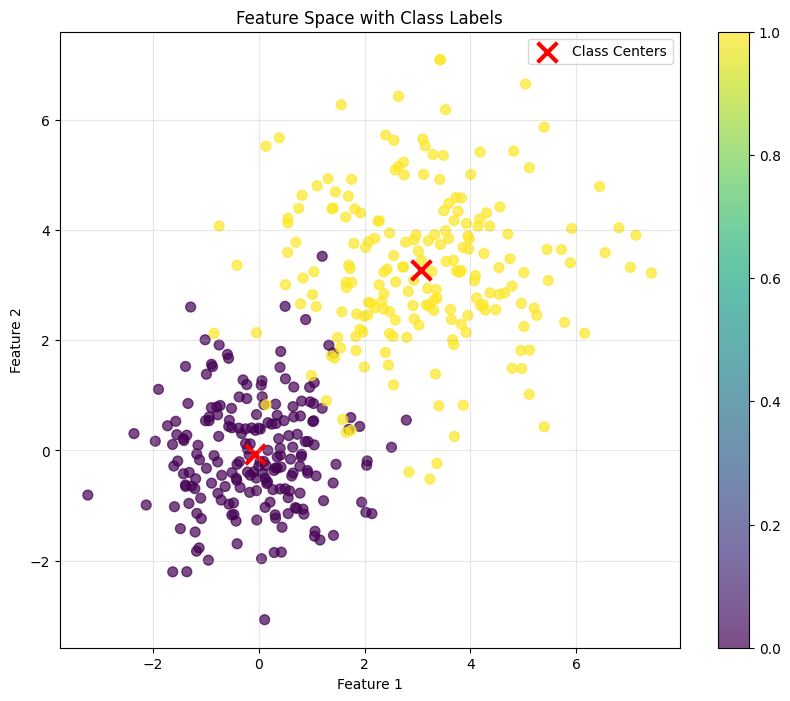


类别中心点:
       feature1  feature2
label                    
0     -0.066735 -0.063308
1      3.075335  3.284084


In [21]:
# 决策边界可视化预览
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    data["feature1"], data["feature2"], c=data["label"], cmap="viridis", alpha=0.7, s=50
)
plt.colorbar(scatter)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Feature Space with Class Labels")
plt.grid(True, alpha=0.3)

# 添加类别中心点
centers = data.groupby("label")[["feature1", "feature2"]].mean()
plt.scatter(
    centers["feature1"],
    centers["feature2"],
    c="red",
    marker="x",
    s=200,
    linewidths=3,
    label="Class Centers",
)
plt.legend()
plt.show()

print(f"\n类别中心点:")
print(centers)